# Universe Time-Line

- author : Sylvie Dagoret-Campagne
- creation date :  2025-07-01
- kernel conda_py313

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

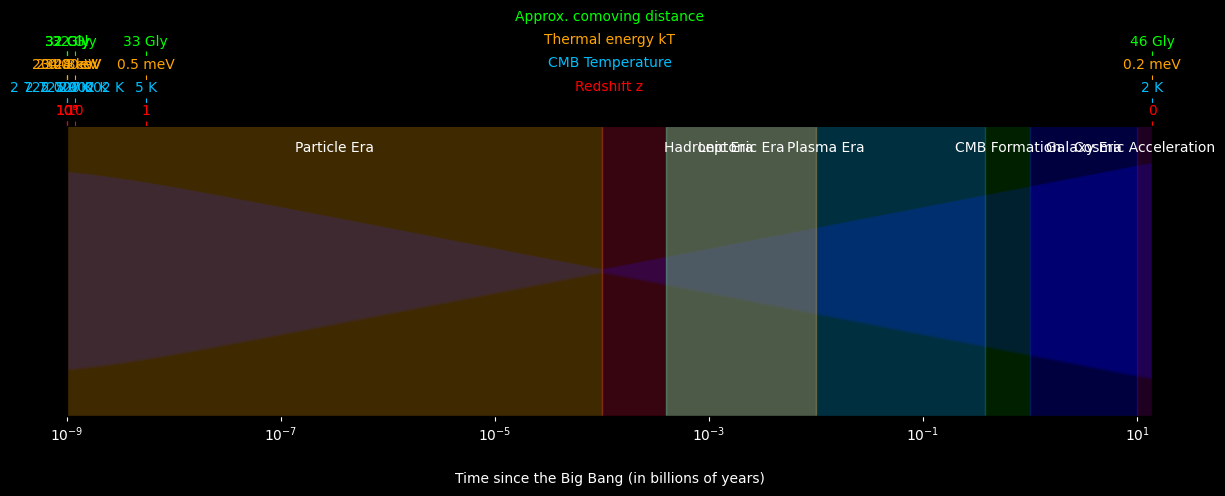

In [2]:


# Approximate physical functions
def redshift_to_temp(z):
    return 2.725 * (1 + z)  # K

def temp_to_energy(T):
    k_B = 8.617333262145e-5  # eV/K
    return T * k_B

def age_to_redshift(age):
    z_vals = np.array([0, 0.5, 1, 3, 10, 1000, 1e6, 1e9])
    age_vals = np.array([13.8, 8, 6, 2, 0.5, 0.0004, 1e-4, 1e-6])
    return np.interp(age, age_vals[::-1], z_vals[::-1])

def redshift_to_age(z):
    z_vals = np.array([0, 0.5, 1, 3, 10, 1000, 1e6, 1e9])
    age_vals = np.array([13.8, 8, 6, 2, 0.5, 0.0004, 1e-4, 1e-6])
    return np.interp(z, z_vals, age_vals)

# Data for axes
age_vals = [1e-9, 1e-6, 1e-3, 1e-1, 1, 13.8]
z_vals = [1e9, 1e6, 1e3, 10, 1, 0]
T_vals = [redshift_to_temp(z) for z in z_vals]
E_vals = [temp_to_energy(T) for T in T_vals]
d_comoving_vals = [46 - (13.8 - a) for a in age_vals]  # Gly approx.

# Main figure
fig, ax_time = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('black')
ax_time.set_facecolor('black')

# Expansion curve
ages = np.logspace(-9, np.log10(13.8), 500)
widths = 0.5 * np.log10(ages + 1e-9) + 2

for i in range(100):
    y_offset = np.sin(i / 10) * 0.05
    ax_time.fill_between(ages, -widths + y_offset, widths + y_offset,
                         color='navy', alpha=0.015)

ax_time.set_xscale('log')
ax_time.set_xlim(1e-9, 13.8)
ax_time.set_ylim(-3.5, 3.5)
ax_time.set_xlabel("Time since the Big Bang (in billions of years)", color='white', labelpad=20)
ax_time.set_yticks([])
ax_time.tick_params(axis='x', colors='white')

# Colored regions
def color_region(xmin, xmax, color, label):
    ax_time.axvspan(xmin, xmax, color=color, alpha=0.25)
    xtext = np.sqrt(xmin * xmax)
    ax_time.text(xtext, 2.8, label, color='white', fontsize=10,
                 ha='center', va='bottom')

color_region(1e-9, 1e-4, 'orange', "Particle Era")
color_region(1e-4, 1e-2, 'crimson', "Hadronic Era")
color_region(1e-2, 0.0004, 'gold', "Leptonic Era")
color_region(0.0004, 0.38, 'deepskyblue', "Plasma Era")
color_region(0.38, 1, 'green', "CMB Formation")
color_region(1, 10, 'blue', "Galaxy Era")
color_region(10, 13.8, 'purple', "Cosmic Acceleration")

# Secondary axes
offsets = [1.0, 1.08, 1.16, 1.24]

# Redshift z
ax_z = ax_time.twiny()
ax_z.spines["top"].set_position(("axes", offsets[0]))
ax_z.set_xlim(ax_time.get_xlim())
ax_z.set_xticks(age_vals)
labels_z = ['10⁹', '10⁶', '10³', '10', '1', '0']
ax_z.set_xticklabels(labels_z, rotation=0, ha='center', color='red')
ax_z.tick_params(axis='x', colors='red', labelsize=10, pad=2)
ax_z.set_xlabel("Redshift z", color='red', labelpad=10)

# Temperature
ax_T = ax_time.twiny()
ax_T.spines["top"].set_position(("axes", offsets[1]))
ax_T.set_xlim(ax_time.get_xlim())
ax_T.set_xticks(age_vals)
labels_T = [f"{int(T):,}".replace(",", " ") + " K" for T in T_vals]
ax_T.set_xticklabels(labels_T, rotation=0, ha='center', color='deepskyblue')
ax_T.tick_params(axis='x', colors='deepskyblue', labelsize=10, pad=2)
ax_T.set_xlabel("CMB Temperature", color='deepskyblue', labelpad=10)

# Thermal energy kT
def format_energy(E):
    if E < 1e-3:
        return f"{E*1e3:.1f} meV"
    elif E < 1:
        return f"{E:.2f} eV"
    elif E < 1e3:
        return f"{E:.1f} eV"
    else:
        return f"{E/1e3:.1f} keV"

ax_E = ax_time.twiny()
ax_E.spines["top"].set_position(("axes", offsets[2]))
ax_E.set_xlim(ax_time.get_xlim())
ax_E.set_xticks(age_vals)
ax_E.set_xticklabels([format_energy(E) for E in E_vals], rotation=0, ha='center', color='orange')
ax_E.tick_params(axis='x', colors='orange', labelsize=10, pad=2)
ax_E.set_xlabel("Thermal energy kT", color='orange', labelpad=10)

# Comoving distance
ax_D = ax_time.twiny()
ax_D.spines["top"].set_position(("axes", offsets[3]))
ax_D.set_xlim(ax_time.get_xlim())
ax_D.set_xticks(age_vals)
labels_D = [f"{round(d)} Gly" for d in d_comoving_vals]
ax_D.set_xticklabels(labels_D, rotation=0, ha='center', color='lime')
ax_D.tick_params(axis='x', colors='lime', labelsize=10, pad=2)
ax_D.set_xlabel("Approx. comoving distance", color='lime', labelpad=10)

plt.subplots_adjust(top=0.78, bottom=0.2)
plt.show()
